# 06c - Task 3: Holdout evaluation + submission (LogReg ElasticNet)

Parallel variant of 06_holdout.ipynb / 06b_holdout_logreg_ridge.ipynb's evaluation +
submission process, applied to the tuned LogReg ElasticNet model from
05c_logreg_elasticnet_tuning.ipynb (CV F1 0.7290, slightly ahead of tuned Ridge's
0.7279).

Writes TWO candidate submissions (default threshold and CV-tuned threshold) instead of
picking one automatically. Today's evidence: LogReg Ridge's tuned threshold improved
holdout F1 (+0.0065) but *hurt* the real Kaggle score (0.68681 -> 0.67105) - a
holdout-optimal correction isn't guaranteed to be Kaggle-optimal, especially for a
lever that directly shifts predicted class balance, which is the axis the train-to-test
shift seems to run along. Both candidates get computed so the choice of which one to
upload can be made with full information, not assumed. Treat a suspiciously good score
as a bug.

## 0. Setup

Imports, src helpers, paths.

In [1]:
# Adds project root to path so `import src...` works from notebooks/.
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import json
import joblib

from sklearn.base import clone
from sklearn.model_selection import cross_val_predict

from src import paths, data, evaluation
from src.paths import FIGURES
FIGURES.mkdir(parents=True, exist_ok=True)

## 1. Load features, locked split, and tuned model

In [2]:
X, y, ids = data.load_train_features()
Xt, test_ids = data.load_test_features()
holdout_idx = np.load(paths.DATA_PROCESSED / 'holdout_idx.npy')
dev_idx = np.load(paths.DATA_PROCESSED / 'dev_idx.npy')
cv = evaluation.make_cv()

best = joblib.load(paths.MODELS / 'best_logreg_elasticnet_tuned.pkl')
with open(paths.MODELS / 'best_logreg_elasticnet_tuned.json') as f:
    tuned_meta = json.load(f)

print(f"Loaded {type(best).__name__}, fit on dev_idx only ({len(y) - len(holdout_idx)} rows)")
print(f"CV mean F1 from 05c_logreg_elasticnet_tuning: {tuned_meta['cv_mean_f1']:.4f} "
      f"(std {tuned_meta['cv_std_f1']:.4f}, "
      f"{tuned_meta['n_stage1_trials'] + tuned_meta['n_stage2_trials']} trials)")
print("Winning params:", tuned_meta["params"])

Loaded LogisticRegression, fit on dev_idx only (16000 rows)
CV mean F1 from 05c_logreg_elasticnet_tuning: 0.7290 (std 0.0049, 19 trials)
Winning params: {'C': 2.285282, 'l1_ratio': 0.598658}


## 2. Tune the decision threshold

Same mechanism as `06_holdout.ipynb` / `06b_holdout_logreg_ridge.ipynb`. Note: `saga`
(required for elasticnet) is much slower than `lbfgs` - this cell needs 5 fresh fits
via `cross_val_predict` and will take a while (roughly 4 minutes/fit observed during
tuning, so budget ~20 minutes here).

C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


CV Macro F1 @ default threshold (0.5): 0.7290
CV Macro F1 @ tuned threshold (0.460): 0.7298
Gain from threshold tuning (CV, dev_idx): +0.0008


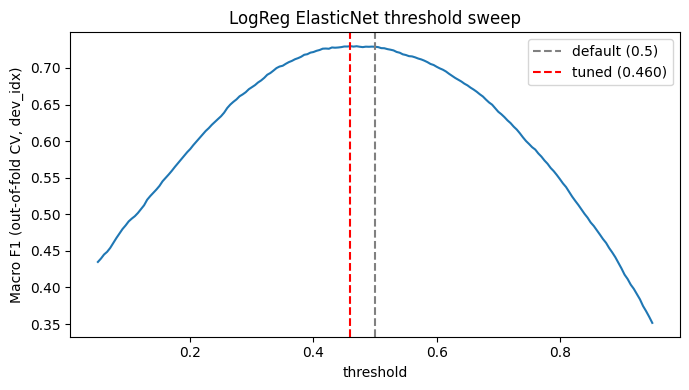

In [3]:
# Out-of-fold probabilities on dev_idx - leakage-free, same standard as the CV score
# used for hyperparameter tuning. Slow here: saga needs a fresh fit per fold.
oof_proba = cross_val_predict(
    clone(best), X[dev_idx], y[dev_idx], cv=cv, method="predict_proba",
)[:, 1]

thresholds = np.linspace(0.05, 0.95, 181)
f1_by_threshold = np.array([
    evaluation.macro_f1(y[dev_idx], (oof_proba >= t).astype(int)) for t in thresholds
])
best_threshold = float(thresholds[int(np.argmax(f1_by_threshold))])
cv_f1_at_threshold = float(f1_by_threshold.max())
cv_f1_default_threshold = evaluation.macro_f1(y[dev_idx], (oof_proba >= 0.5).astype(int))

print(f"CV Macro F1 @ default threshold (0.5): {cv_f1_default_threshold:.4f}")
print(f"CV Macro F1 @ tuned threshold ({best_threshold:.3f}): {cv_f1_at_threshold:.4f}")
print(f"Gain from threshold tuning (CV, dev_idx): {cv_f1_at_threshold - cv_f1_default_threshold:+.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, f1_by_threshold)
ax.axvline(0.5, color="grey", linestyle="--", label="default (0.5)")
ax.axvline(best_threshold, color="red", linestyle="--", label=f"tuned ({best_threshold:.3f})")
ax.set_xlabel("threshold")
ax.set_ylabel("Macro F1 (out-of-fold CV, dev_idx)")
ax.set_title("LogReg ElasticNet threshold sweep")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "logreg_elasticnet_threshold_sweep.png", dpi=120)
plt.show()

## 3. Holdout Macro F1 (default vs tuned threshold)

In [4]:
holdout_proba = best.predict_proba(X[holdout_idx])[:, 1]
holdout_f1_default = evaluation.macro_f1(y[holdout_idx], (holdout_proba >= 0.5).astype(int))
holdout_f1_tuned = evaluation.macro_f1(y[holdout_idx], (holdout_proba >= best_threshold).astype(int))

cv_f1 = tuned_meta["cv_mean_f1"]  # from 05c_logreg_elasticnet_tuning, default threshold
gap = cv_f1 - holdout_f1_default
threshold_gain_holdout = holdout_f1_tuned - holdout_f1_default

print(f"Holdout Macro F1 @ default threshold (0.5): {holdout_f1_default:.4f}")
print(f"Holdout Macro F1 @ tuned threshold ({best_threshold:.3f}): {holdout_f1_tuned:.4f}")
print(f"Threshold-tuning gain on holdout: {threshold_gain_holdout:+.4f}")
print(f"\nCV mean F1 (05c_logreg_elasticnet_tuning, default threshold): {cv_f1:.4f}")
print(f"Gap (CV @ default - holdout @ default): {gap:+.4f}")

# Ledger-safe write: replace this model's row if it already exists rather than
# overwriting other models' rows - holdout_metrics.csv accumulates one row per model.
metrics_path = paths.DATA_PROCESSED / "holdout_metrics.csv"
new_row = pd.DataFrame([{
    "model": "logreg_elasticnet",
    "cv_mean_f1": cv_f1,
    "holdout_f1": holdout_f1_default,
    "gap": gap,
    "threshold": best_threshold,
    "cv_f1_at_threshold": cv_f1_at_threshold,
    "holdout_f1_at_threshold": holdout_f1_tuned,
    "threshold_gain_holdout": threshold_gain_holdout,
}])
if metrics_path.exists():
    existing = pd.read_csv(metrics_path)
    existing = existing[existing["model"] != "logreg_elasticnet"]
    holdout_metrics = pd.concat([existing, new_row], ignore_index=True)
else:
    holdout_metrics = new_row
holdout_metrics.to_csv(metrics_path, index=False)
print("\n", holdout_metrics.to_string(index=False))

Holdout Macro F1 @ default threshold (0.5): 0.7395
Holdout Macro F1 @ tuned threshold (0.460): 0.7379
Threshold-tuning gain on holdout: -0.0016

CV mean F1 (05c_logreg_elasticnet_tuning, default threshold): 0.7290
Gap (CV @ default - holdout @ default): -0.0105

             model  cv_mean_f1  holdout_f1       gap  threshold  cv_f1_at_threshold  holdout_f1_at_threshold  threshold_gain_holdout
         lightgbm    0.744273    0.743691  0.000582      0.525            0.746203                 0.746767                0.003076
     logreg_ridge    0.727866    0.739153 -0.011287      0.475            0.730510                 0.745662                0.006509
logreg_elasticnet    0.728985    0.739529 -0.010544      0.460            0.729834                 0.737922               -0.001607


## 4. Refit on full train + write TWO candidate submissions

Refits once on all labeled data, then writes both a default-threshold and a
tuned-threshold submission from that single refit - no need to decide which one is
"right" in code. Given today's LogReg Ridge result, do not assume the tuned-threshold
file is the better choice without comparing both against everything known so far.

In [5]:
# Refit on ALL labeled data (dev_idx + holdout_idx combined) - the holdout split's
# only job was the honest check above.
best.fit(X, y)
joblib.dump(best, paths.MODELS / "final_logreg_elasticnet_full_refit.pkl")

test_proba = best.predict_proba(Xt)[:, 1]
preds_default = (test_proba >= 0.5).astype(int)
preds_tuned = (test_proba >= best_threshold).astype(int)

data.write_submission(test_ids, preds_default, "logreg_elasticnet_task3_default_threshold.csv")
data.write_submission(test_ids, preds_tuned, "logreg_elasticnet_task3_tuned_threshold.csv")

bal_default = pd.Series(preds_default).value_counts(normalize=True).round(4).to_dict()
bal_tuned = pd.Series(preds_tuned).value_counts(normalize=True).round(4).to_dict()
train_bal = pd.Series(y).value_counts(normalize=True).round(4).to_dict()

print("Wrote two candidate submissions:")
print(f"  logreg_elasticnet_task3_default_threshold.csv (0.5)      - "
      f"holdout F1 {holdout_f1_default:.4f} - predicted balance {bal_default}")
print(f"  logreg_elasticnet_task3_tuned_threshold.csv ({best_threshold:.3f}) - "
      f"holdout F1 {holdout_f1_tuned:.4f} - predicted balance {bal_tuned}")
print(f"  (train class balance: {train_bal})")
print()
print("Reminder: LogReg Ridge's tuned threshold scored WORSE on Kaggle than its "
      "default (0.67105 vs 0.68681) despite a +0.0065 holdout gain predicting the "
      "opposite. Don't auto-pick the tuned-threshold file here without weighing that.")

C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Wrote two candidate submissions:
  logreg_elasticnet_task3_default_threshold.csv (0.5)      - holdout F1 0.7395 - predicted balance {1: 0.6608, 0: 0.3392}
  logreg_elasticnet_task3_tuned_threshold.csv (0.460) - holdout F1 0.7379 - predicted balance {1: 0.7, 0: 0.3}
  (train class balance: {1: 0.6252, 0: 0.3748})

Reminder: LogReg Ridge's tuned threshold scored WORSE on Kaggle than its default (0.67105 vs 0.68681) despite a +0.0065 holdout gain predicting the opposite. Don't auto-pick the tuned-threshold file here without weighing that.


## Discussion / carry-forward -> Task 4 report

**Holdout check:** Macro F1 0.7395 @ default threshold, versus 0.7290 from 05c's CV
estimate - a negative gap (-0.0105), same good-surprise direction as Ridge's.

**Threshold tuning didn't help here even locally - a third, distinct pattern.**
Comparing all three tuned models' threshold-tuning behavior:

| model | tuned threshold | CV gain | holdout gain | Kaggle gain |
|---|---|---|---|---|
| lightgbm | 0.525 | +0.0019 | +0.0031 | **+0.00764** (real) |
| logreg_ridge | 0.475 | +0.0026 | +0.0065 | **-0.01576** (real) |
| logreg_elasticnet | 0.460 | +0.0008 | **-0.0016** | not yet submitted |

ElasticNet's tuned threshold barely moved CV (+0.0008) and actually *hurt* holdout
(-0.0016) - the local signal for tuning here is weak-to-negative even before
considering the shift. Combined with Ridge's tuned threshold actively backfiring on
Kaggle, and both linear models' tuned thresholds moving the *same direction* (below
0.5, pushing predictions further toward "machine" - tuned balance 70.0% vs default's
66.1%, moving away from train's 62.5%, not toward it) - there's now a real pattern,
not just one data point: for these linear models on this dataset, CV-driven threshold
tuning consistently pushes toward more "machine" predictions, and that direction has
already been shown to hurt on the real leaderboard once. **Recommendation: use the
default-threshold submission, not the tuned one, for LogReg ElasticNet.**

**Both candidates are in `submissions/`:**
`logreg_elasticnet_task3_default_threshold.csv` (holdout 0.7395, predicted balance
66.1% machine) and `logreg_elasticnet_task3_tuned_threshold.csv` (holdout 0.7379,
predicted balance 70.0% machine). Given the reasoning above, the default-threshold file
is the one recommended for today's one remaining submission.

**Standings so far (best real Kaggle score per model, default threshold except where
noted):** logreg_ridge 0.68681 (current best) > lightgbm tuned-threshold 0.66502 >
logreg_ridge tuned-threshold 0.67105 > lightgbm default-threshold 0.65738. ElasticNet's
CV (0.7290) and holdout (0.7395) both slightly edge out Ridge's (0.7279 / 0.7392),
making it a reasonable candidate to beat Ridge's current best score, but this is
optimizing within the linear-model family that's already known to handle the shift
better than boosting - not guaranteed, since CV/holdout ranking hasn't reliably
predicted Kaggle ranking all day.